## Load packages


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pylab as pl
import scanpy as sc
from anndata import AnnData
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [ ]:
import FGOT
from FGOT import preprocess as pre
from FGOT import fgot_sparse_tensor, fgot_tol, align
from FGOT import metrics as mt

## Load data


In [ ]:
import pickle

adata_path = "/home/nas3/biod/yangchenghui/proj2/proj2_on_SpatialP22/UniG_result/P22_UniG_adata_dict.pkl"
with open(adata_path, "rb") as f:
    dict_adata = pickle.load(f)

adata_C = dict_adata["C"]
adata_G = dict_adata["G"]
adata_P = dict_adata["P"]
adata_M = dict_adata["M"]

adata_C, adata_G, adata_P, adata_M


(AnnData object with n_obs × n_vars = 9215 × 50
     obs: 'entity_anno', 'celltype', 'mclust'
     uns: 'neighbors', 'umap', 'mclust_colors', 'celltype_colors'
     obsm: 'spatial', 'X_umap'
     obsp: 'distances', 'connectivities',
 AnnData object with n_obs × n_vars = 1797 × 50
     obs: 'entity_anno',
 AnnData object with n_obs × n_vars = 50092 × 50
     obs: 'entity_anno',
 AnnData object with n_obs × n_vars = 107 × 50
     obs: 'entity_anno')

In [4]:
RNA_cluster = (
    pd.DataFrame(adata_C.obs["mclust"])
    .reset_index()
    .rename(columns={"index": "cell", "mclust": "cluster"})
)
RNA_cluster["cluster"] = RNA_cluster["cluster"].astype(str)
ATAC_cluster = RNA_cluster.copy()
ATAC_cluster


,cell,cluster
0,ACATTGGCGTGTTCTA,14
1,AGATGTACCAACCACA,11
2,CTAAGGTCCCTAATCC,6
3,AGCACCTCAGGCTAAC,1
4,GTCTGTCAGTACGCAA,13
...,...,...
9210,GGTGCGAAATCATTCC,9
9211,CGGAAGAAGTCTGTCA,11
9212,CAAGACTAGTACGCAA,13
9213,CCTAATCCCACCTTAC,6


In [ ]:
cell_emb = adata_C.copy()
gene_emb = adata_G.copy()
peak_emb = adata_P.copy()
motif_emb = adata_M.copy()

motif_expression_matrix = cell_emb.X @ motif_emb.X.T
peak_expression_matrix = cell_emb.X @ peak_emb.X.T
target_gene_expression_matrix = cell_emb.X @ gene_emb.X.T

adata_motif_expression = AnnData(X=motif_expression_matrix)
adata_motif_expression.obs_names = cell_emb.obs_names
adata_motif_expression.var_names = motif_emb.obs_names
adata_motif_expression.obs["label"] = cell_emb.obs["mclust"].astype(str).values
adata_motif_expression.obsm["spatial"] = cell_emb.obsm["spatial"]

adata_peak_expression = AnnData(X=peak_expression_matrix)
adata_peak_expression.obs_names = cell_emb.obs_names
adata_peak_expression.var_names = peak_emb.obs_names
adata_peak_expression.obs["label"] = cell_emb.obs["mclust"].astype(str).values
adata_peak_expression.obsm["spatial"] = cell_emb.obsm["spatial"]

adata_TG_expression = AnnData(X=target_gene_expression_matrix)
adata_TG_expression.obs_names = cell_emb.obs_names
adata_TG_expression.var_names = gene_emb.obs_names
adata_TG_expression.obs["label"] = cell_emb.obs["mclust"].astype(str).values
adata_TG_expression.obsm["spatial"] = cell_emb.obsm["spatial"]

adata_TG_expression, adata_peak_expression, adata_motif_expression


(AnnData object with n_obs × n_vars = 9215 × 1797
     obs: 'label'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 9215 × 50092
     obs: 'label'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 9215 × 107
     obs: 'label'
     obsm: 'spatial')

/tmp/ipykernel_468211/583672887.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_TG_expression, img_key=None, color=["label"],spot_size = 1)


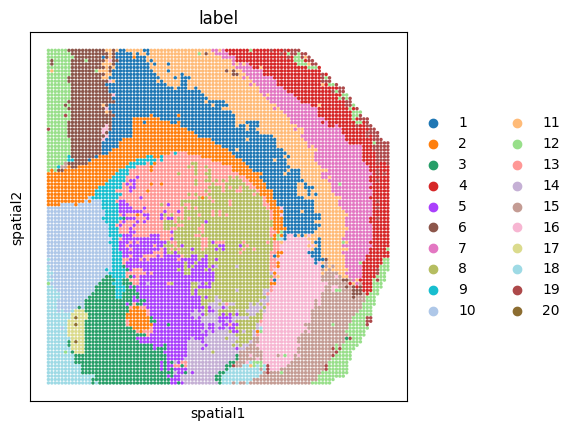

In [6]:
sc.pl.spatial(
    adata_TG_expression,
    img_key=None,
    color=["label"],
    spot_size=1,
)


Further feature filtering


In [7]:
adata_TG_expression.obs["label"] = adata_TG_expression.obs["label"].astype("category")
sc.tl.rank_genes_groups(adata_TG_expression, groupby="label", method="wilcoxon")

marker_genes_dict = {}
all_marker_genes = set()

print("Extracting the top 50 marker genes for each label...")
for label in adata_TG_expression.obs["label"].cat.categories:
    df_genes = sc.get.rank_genes_groups_df(adata_TG_expression, group=label)
    top50 = df_genes["names"].head(50).tolist()

    marker_genes_dict[label] = top50
    all_marker_genes.update(top50)

all_marker_genes_list = sorted(all_marker_genes)
print(f"Extracted {len(all_marker_genes_list)} unique marker genes.")

adata_TG_expression_subset = adata_TG_expression[:, all_marker_genes_list].copy()
print(f"Filtered adata shape: {adata_TG_expression_subset.shape}")


/home/yangchenghui/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/yangchenghui/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/yangchenghui/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/yangchenghui/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/yangchenghui/.local/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home

Extracting the top 50 marker genes for each label...
Extracted 658 unique marker genes.
Filtered adata shape: (9215, 658)


In [ ]:
gene_peak_path = "/home/nas3/biod/yangchenghui/proj2_on_SpatialP22/P22_SIMBA_result/adata_GenePeak_final.h5ad"
adata_GP = sc.read_h5ad(gene_peak_path)
adata_GP

AnnData object with n_obs × n_vars = 1797 × 50092

In [ ]:
feature_matrix = pd.DataFrame(
    data=adata_GP.X,
    index=adata_GP.obs.index,
    columns=adata_GP.var.index,
).T
feature_matrix[:3]

,Oprk1,St18,Pcmtd1,A830018L16Rik,Sulf1,Slco5a1,Tfap2d,Tfap2b,Mcm3,Kcnq5,...,Tro,Huwe1,Cnksr2,Map7d2,Scml2,Bmx,Gpm6b,Tmsb4x,Arhgap6,Ddx3y
chr2:38770826-38771649,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chr16:76227725-76228585,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
chrX:103563304-103564226,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
genes_of_interest = feature_matrix[all_marker_genes_list]
peaks_in_regions = genes_of_interest[genes_of_interest == 1].dropna(how="all")
peak_set = peaks_in_regions.index.tolist()

print("Peaks in the 250kb regions of the selected genes:", len(peak_set))

adata_peak_expression_subset = adata_peak_expression[:, peak_set].copy()
print(f"Filtered adata shape: {adata_peak_expression_subset.shape}")


Peaks in the 250kb regions of the selected genes: 21966
Filtered adata shape: (9215, 21966)


In [ ]:
feature_matrix_new = feature_matrix.loc[peak_set, all_marker_genes_list].copy()
feature_matrix_new[feature_matrix_new == 0] = np.inf
feature_matrix_new

/tmp/ipykernel_4081586/4210852074.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'inf' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  feature_matrix_new[feature_matrix_new == 0] = np.inf


In [20]:
X1 = adata_peak_expression_subset.X
X2 = adata_TG_expression_subset.X
n1, d1 = X1.shape
n2, d2 = X2.shape

print("Dimensions of input datasets:", "X1 =", X1.shape, "X2 =", X2.shape)

basic_labels1 = np.array(RNA_cluster["cluster"])
basic_labels2 = np.array(ATAC_cluster["cluster"])
print(
    "Dimensions of basic labels:",
    "basic_labels1 =",
    basic_labels1.shape,
    "basic_labels2 =",
    basic_labels2.shape,
)

cell_names1 = list(adata_TG_expression_subset.obs_names)
cell_names2 = list(adata_peak_expression_subset.obs_names)
peak_names = list(adata_peak_expression_subset.var_names)
gene_names = list(adata_TG_expression_subset.var_names)


Dimensions of input datasets are:  X1 =  (9215, 21966)  X2 =  (9215, 658)
Dimensions of basic_labels are:  basic_labels1 =  (9215,)  basic_labels2 =  (9215,)


## Build a priori feature graph


In [14]:
feature_matrix_new[:5]

,A830036E02Rik,A830082K12Rik,AI593442,AW551984,Aatk,Abi3bp,Ablim2,Acta2,Actn2,Adam33,...,Zbtb18,Zbtb20,Zcchc18,Zdbf2,Zer1,Zfhx3,Zic1,Zic4,Zmat4,Zmynd8
chrX:103563304-103564226,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
chr16:22545005-22545837,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
chr15:76519306-76520130,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
chrX:7670350-7671116,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf
chr13:55000159-55001069,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf,...,inf,inf,inf,inf,inf,inf,inf,inf,inf,inf


## Compute cost across modalities


In [15]:
adata_graph = adata_C.copy()
n_cells = adata_graph.shape[0]
snn = np.asarray(adata_graph.obsp["connectivities"].todense())
snn[np.arange(n_cells), np.arange(n_cells)] = 1
snn.shape


(9215, 9215)

In [16]:
cost = np.exp(1 - snn)
cost = cost - np.min(cost)
cost = pd.DataFrame(cost, index=adata_C.obs_names, columns=adata_C.obs_names)
cost.head()


,ACATTGGCGTGTTCTA,AGATGTACCAACCACA,CTAAGGTCCCTAATCC,AGCACCTCAGGCTAAC,GTCTGTCAGTACGCAA,AACCGAGACTAAGGTC,TTCACGCAATCATTCC,CAAGACTAACACAGAA,CAAGGAGCAAGGACAC,AAGGTACAAGAGTCAA,...,AGAGTCAACATACCAA,AGATGTACCGCTGATC,AGTGGTCAAACTCACC,AATGTTGCGTACGCAA,TTCACGCACCGACAAC,GGTGCGAAATCATTCC,CGGAAGAAGTCTGTCA,CAAGACTAGTACGCAA,CCTAATCCCACCTTAC,AATCCGTCCGGAAGAA
ACATTGGCGTGTTCTA,0.000000,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,...,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282
AGATGTACCAACCACA,1.718282,0.000000,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,...,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282
CTAAGGTCCCTAATCC,1.718282,1.718282,0.000000,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,...,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282
AGCACCTCAGGCTAAC,1.718282,1.718282,1.718282,0.000000,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,...,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282
GTCTGTCAGTACGCAA,1.718282,1.718282,1.718282,1.718282,0.000000,1.718282,1.718282,1.718282,1.718282,1.718282,...,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282,1.718282


Text(0.5, 1.0, 'cost across modality')

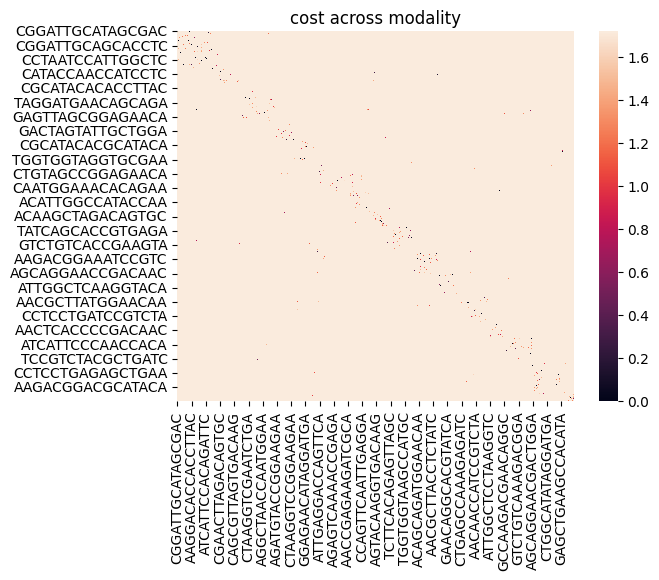

In [16]:
sorted_cols = np.argsort(basic_labels1)
sorted_rows = np.argsort(basic_labels2)
sorted_cost = cost.iloc[sorted_cols, sorted_rows]

sns.heatmap(sorted_cost)
pl.title("Cost across modality")


## Scale


In [17]:
scaler = StandardScaler()
X1 = scaler.fit_transform(X1)
X2 = scaler.fit_transform(X2)

X1 = pd.DataFrame(X1, index=cell_names1, columns=peak_names)
X2 = pd.DataFrame(X2, index=cell_names2, columns=gene_names)


## Solve the feature-guided optimal transport problem


In [18]:
P_tensor = fgot_sparse_tensor(
    X1,
    X2,
    feature_matrix_new,
    cost,
    ATAC_cluster,
    RNA_cluster,
    minibatch=1,
    batchsize=400,
    pair=True,
    device="cuda:1",
    eps_p=1e-1,
)

import pickle

with open(
    "/home/nas3/biod/yangchenghui/proj2_on_SpatialP22/downstream_regulation/FGOT_result/P_tensor_P22.pickle",
    "wb",
) as file:
    pickle.dump(P_tensor, file)


minibatch = 1 and device =  cuda:1
the total number of computing batch is  23


100%|██████████| 23/23 [9:56:12<00:00, 1555.31s/it]  


In [ ]:
# import pickle

# with open(
#     "/home/nas3/biod/yangchenghui/proj2_on_SpatialP22/downstream_regulation/FGOT_result/P_tensor_P22.pickle",
#     "rb",
# ) as file:
#     P_tensor = pickle.load(file)


## Make multi-omics alignment from the transport tensor


In [19]:
P = fgot_tol(P_tensor)
P.shape

100%|██████████| 24236/24236 [2:13:01<00:00,  3.04it/s]  


(9215, 9215)

In [25]:
# np.save(
#     "/home/nas3/biod/yangchenghui/proj2_on_SpatialP22/downstream_regulation/FGOT_result/P22_P_2dim.npy",
#     P,
# )
P = np.load(
    "/home/nas3/biod/yangchenghui/proj2_on_SpatialP22/downstream_regulation/FGOT_result/P22_P_2dim.npy"
)


Text(0.5, 1.0, 'optimal transport matrix')

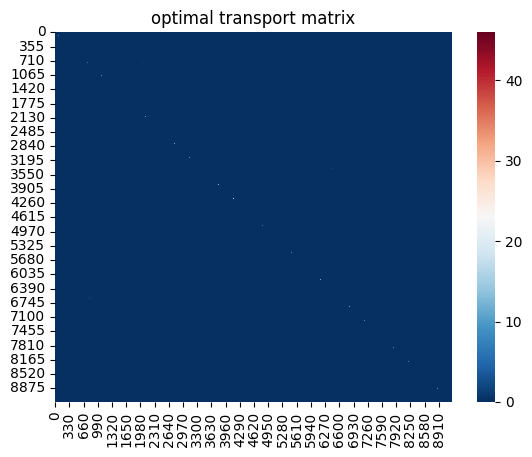

In [ ]:
P = pd.DataFrame(P)
sorted_cols = np.argsort(basic_labels1)
sorted_rows = np.argsort(basic_labels2)
sorted_transport = P.iloc[sorted_cols, sorted_rows]

sns.heatmap(sorted_transport, cmap="RdBu_r")
pl.title("Optimal transport matrix")


In [27]:
X1_aligned, X2_aligned = align(X1, X2, P, mode="RNA2ATAC")

In [28]:
spatial = np.asarray(adata_C.obsm["spatial"])
data_aligned = np.concatenate((X1_aligned, X2_aligned), axis=0)

adata_aligned = AnnData(data_aligned)
adata_aligned.obs["batch"] = np.array(["ATAC"] * n1 + ["RNA"] * n2)
adata_aligned.obsm["spatial"] = np.concatenate((spatial, spatial), axis=0)

sc.tl.pca(adata_aligned)
sc.pp.neighbors(adata_aligned, n_neighbors=15, n_pcs=40)
sc.tl.umap(adata_aligned)


/home/yangchenghui/miniconda3/envs/env_FGOT/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


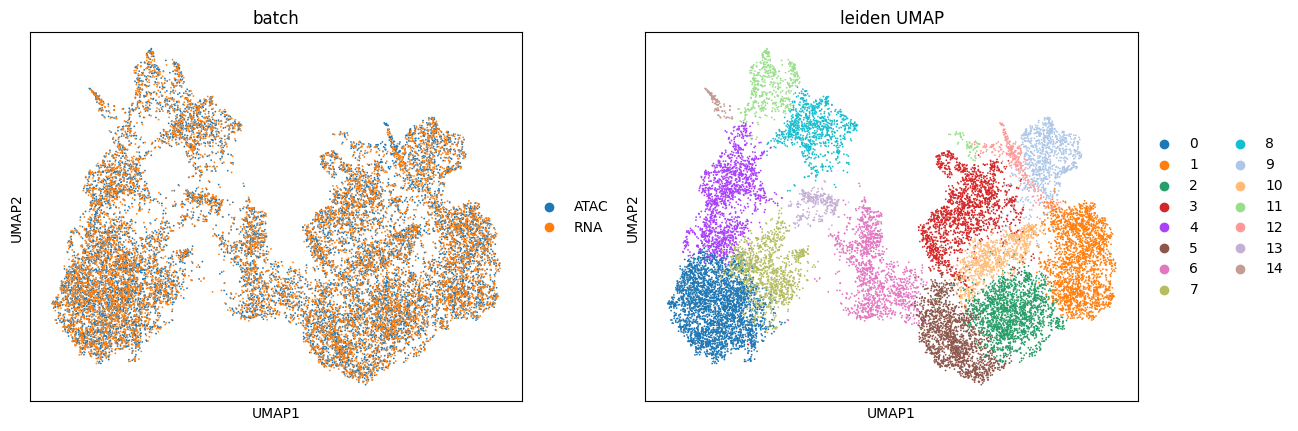

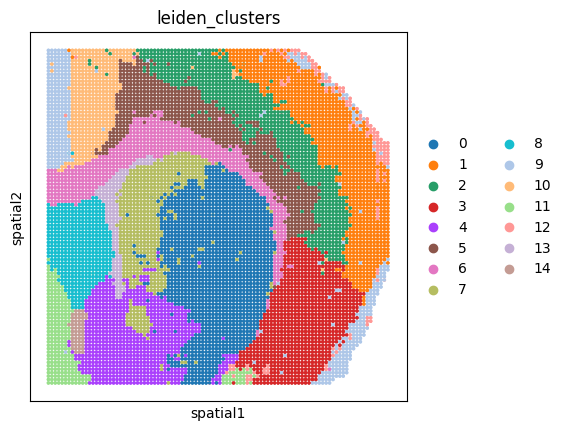

In [37]:
sc.tl.leiden(adata_aligned, key_added="leiden_clusters", resolution=1)
sc.pl.umap(
    adata_aligned,
    color=["batch", "leiden_clusters"],
    title=["batch", "leiden UMAP"],
    show=False,
)
sc.pl.spatial(
    adata_aligned,
    img_key=None,
    color="leiden_clusters",
    spot_size=1,
)


In [38]:
fgot_adata_path = "/home/nas3/biod/yangchenghui/proj2_on_SpatialP22/downstream_regulation/FGOT_result/P22_FGOT_adata.h5ad"
adata_aligned.write_h5ad(fgot_adata_path)


# Downstream regulatory analysis


In [ ]:
# import pickle
# with open('/home/nas3/biod/yangchenghui/proj2_on_SpatialP22/downstream_regulation/FGOT_result/P_tensor_P22_batchsize600_p1e-1.pickle', 'rb') as file:
#     P_tensor = pickle.load(file)

In [42]:
import numpy as np
import pandas as pd
from tqdm import tqdm

def fgot_analysis_link_intensity_for_each_celltype(P_tensor, feature_matrix, cellatac_cluster, cellrna_cluster, mode='ATAC2RNA'):
    # Transpose feature matrix if mode is RNA2ATAC
    if mode == 'RNA2ATAC':
        feature_matrix = feature_matrix.T
    
    # Build a dictionary to store gene pairs
    pairs = {}
    # Use list(P_tensor.keys()) to avoid potential iterator issues during tqdm wrapping
    for key in tqdm(list(P_tensor.keys()), desc="Building pairs dictionary"):
        f_i, f_j = (key[0], key[1]) if mode == 'RNA2ATAC' else (key[1], key[0])
        pairs.setdefault(f_i, []).append(f_j)
    
    # Get common clusters (intersection of ATAC and RNA clusters)
    clusters = list(set(cellrna_cluster) & set(cellatac_cluster))
    
    # Precompute the indices for each cluster in both cell types to avoid repeated lookups
    # This vectorization is much faster than list comprehensions inside the loop
    cluster_indices_atac = {cluster: np.where(np.array(cellatac_cluster) == cluster)[0] for cluster in clusters}
    cluster_indices_rna = {cluster: np.where(np.array(cellrna_cluster) == cluster)[0] for cluster in clusters}

    intensity_s = []
    
    # Outer loop: Iterate over Genes (f_i)
    for f_i, f_j_list in tqdm(pairs.items(), desc="Processing gene pairs"):
        # Initialize intensity matrix for this gene pair
        # Rows: clusters, Cols: peaks (f_j)
        int_i = np.zeros((len(clusters), len(f_j_list)))

        # OPTIMIZATION: Iterate over Peaks (f_j) FIRST, then Clusters
        # This is the critical speedup: we only densify the sparse matrix ONCE per Gene-Peak pair
        for j, f_j in enumerate(f_j_list):
            key_j = (f_i, f_j) if mode == 'RNA2ATAC' else (f_j, f_i)
            
            # Get matrix and densify ONCE
            if key_j in P_tensor:
                sparse_matrix = P_tensor[key_j]
                # Check if it needs densifying (it's likely a sparse matrix)
                if hasattr(sparse_matrix, 'todense'):
                    dense_matrix = sparse_matrix.todense()
                else:
                    dense_matrix = sparse_matrix

                # Inner loop: Iterate over Clusters
                # Now we just slice the already dense matrix, which is fast
                for i, cluster in enumerate(clusters):
                    # Retrieve precomputed indices
                    index1 = cluster_indices_atac[cluster]  # ATAC indices
                    index2 = cluster_indices_rna[cluster]   # RNA indices
                    
                    if len(index1) > 0 and len(index2) > 0:
                        # Compute mean intensity
                        int_i[i, j] = dense_matrix[np.ix_(index1, index2)].mean()
        
        # Convert to DataFrame
        # Original logic: Rows=Clusters, Cols=Peaks
        int_i_df = pd.DataFrame(int_i, index=clusters, columns=f_j_list)
        
        # Transpose to match required output format: Rows=Gene-Peak combinations, Cols=Clusters
        int_i_df = int_i_df.T 
        
        # Rename indices to "Gene-Peak" format
        int_i_df.index = [f"{f_i}-{peak}" for peak in int_i_df.index]
        
        intensity_s.append(int_i_df)
    
    # Combine all intensity DataFrames into one
    if intensity_s:
        intensity_df = pd.concat(intensity_s, axis=0)
    else:
        intensity_df = pd.DataFrame()
        
    return intensity_df

In [43]:
intensity_df = fgot_analysis_link_intensity_for_each_celltype(
    P_tensor,
    feature_matrix,
    basic_labels1,
    basic_labels2,
    mode="RNA2ATAC",
)

regulatory_scores_path = "/home/nas3/biod/yangchenghui/proj2_on_SpatialP22/downstream_regulation/FGOT_result/P22_regulatory_scores.txt"
intensity_df.to_csv(regulatory_scores_path, sep="\t")
intensity_df


Processing gene pairs: 100%|██████████| 21966/21966 [1:55:34<00:00,  3.17it/s]  


,3,16,17,11,14,2,18,9,13,8,6,10,4,1,7,12,15,20,5,19
chrX:103563304-103564226-Slc16a2,1.318011e-06,5.379441e-07,6.534108e-06,6.787249e-07,1.432797e-06,1.216442e-06,1.031898e-07,2.522262e-06,1.272603e-06,2.769447e-07,6.651090e-06,1.480221e-07,2.427822e-06,6.153916e-07,1.237605e-06,2.581102e-07,1.317301e-06,0.000000,1.111553e-06,0.000000e+00
chrX:103563304-103564226-Xist,1.092049e-07,7.127848e-08,0.000000e+00,1.663718e-06,1.954038e-06,4.406724e-07,2.133325e-07,8.883051e-08,6.794308e-07,3.590444e-07,1.750881e-07,4.778910e-09,2.039845e-06,2.754131e-07,1.661909e-06,9.150201e-07,1.727578e-07,0.000000,8.692892e-07,1.785632e-06
chr16:22545005-22545837-Dgkg,1.931246e-07,5.260620e-07,1.344609e-05,6.581517e-08,1.723561e-07,2.880935e-08,3.805984e-07,4.480548e-08,1.983878e-08,4.108984e-08,2.436719e-06,4.525369e-06,2.322637e-07,1.213291e-07,9.375666e-08,1.892826e-07,3.647524e-07,0.000768,5.314070e-08,2.641519e-11
chr15:76519306-76520130-Scrt1,3.132205e-08,4.010081e-07,0.000000e+00,1.372968e-06,2.179858e-07,5.689543e-09,1.720942e-07,3.838762e-09,2.594183e-08,1.194639e-07,1.576950e-07,6.619134e-09,2.857628e-07,9.750639e-07,3.253879e-06,4.387335e-09,1.980608e-07,0.000000,6.020088e-08,0.000000e+00
chrX:7670350-7671116-Syp,2.228638e-08,1.967248e-06,0.000000e+00,1.537353e-06,2.907377e-11,5.664666e-08,3.523535e-07,6.908060e-11,1.574000e-09,2.883855e-10,3.849885e-06,2.268781e-09,2.384769e-06,1.350385e-06,1.253550e-06,8.627651e-07,1.980162e-06,0.000000,1.856958e-12,2.843441e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chr11:88266109-88267003-Msi2,4.470337e-07,3.094934e-07,2.272371e-05,1.665559e-07,4.495418e-07,3.275672e-07,2.408155e-06,2.445408e-05,4.913423e-07,5.820978e-08,3.390932e-07,3.765589e-07,7.508443e-08,5.582312e-08,5.719292e-08,9.605645e-07,1.110981e-06,0.000246,1.306276e-07,5.081607e-07
chr7:80245937-80246830-Furin,1.154988e-06,1.955636e-07,3.432561e-05,6.478616e-08,1.677900e-07,1.568605e-06,1.259058e-06,9.671008e-06,5.333333e-07,6.823446e-08,2.043028e-06,1.729255e-06,5.757228e-08,7.443141e-07,3.646830e-08,4.370263e-08,2.453983e-07,0.000767,1.801146e-07,0.000000e+00
chr7:80245937-80246830-Prc1,6.588647e-07,7.925935e-08,1.326645e-05,7.289113e-08,2.986534e-08,2.751482e-06,8.266566e-07,3.985663e-05,9.034326e-07,1.909163e-08,1.040071e-06,1.623600e-06,1.117523e-07,4.380707e-07,4.096619e-08,5.319885e-07,1.568106e-07,0.000171,1.154813e-07,1.268745e-07
chr5:65955682-65956116-N4bp2,7.190509e-06,9.189026e-07,6.512621e-05,4.303064e-08,2.119007e-06,5.452947e-08,1.509177e-06,3.842028e-06,1.871854e-06,1.351448e-06,1.398760e-06,4.814246e-06,7.664485e-09,3.671296e-07,2.355431e-08,3.495805e-09,8.716127e-07,0.001504,2.388611e-06,0.000000e+00


In [122]:
import pandas as pd


def transform_to_unified_df(intensity_df):
    all_data = []
    clusters = intensity_df.columns.tolist()

    for cluster in clusters:
        cluster_data = intensity_df[cluster].reset_index()
        cluster_data.columns = ["peak-gene", "score"]
        cluster_data[["peak", "gene"]] = cluster_data["peak-gene"].str.rsplit(
            "-",
            n=1,
            expand=True,
        )
        cluster_data["celltype"] = cluster
        all_data.append(cluster_data[["gene", "peak", "score", "celltype"]])

    unified_df = pd.concat(all_data, ignore_index=True)
    return unified_df.sort_values(by=["gene", "celltype"])


cluster_dfs = transform_to_unified_df(intensity_df)
cluster_dfs


,gene,peak,score,celltype
315334,A830036E02Rik,chr11:99182565-99183375,8.833433e-08,1
316043,A830036E02Rik,chr11:99307294-99308133,2.751487e-08,1
317295,A830036E02Rik,chr11:99430486-99431350,2.357593e-08,1
318034,A830036E02Rik,chr11:99644169-99644869,7.726461e-08,1
318396,A830036E02Rik,chr11:99398430-99399335,1.291017e-08,1
...,...,...,...,...
191700,Zmynd8,chr2:165976806-165977665,2.221235e-08,9
191907,Zmynd8,chr2:165852383-165853035,9.523063e-08,9
192607,Zmynd8,chr2:165782189-165783029,1.054297e-06,9
192959,Zmynd8,chr2:165992239-165993084,2.557712e-06,9


In [154]:
# cluster_dfs.to_csv(
#     "/home/nas3/biod/yangchenghui/proj2_on_SpatialP22/downstream_regulation/FGOT_result/P22_regulatory_cluster.csv",
#     index=False,
# )
regulatory_cluster_path = "/home/nas3/biod/yangchenghui/proj2_on_SpatialP22/downstream_regulation/FGOT_result/P22_regulatory_cluster.csv"
cluster_dfs = pd.read_csv(regulatory_cluster_path)
cluster_dfs


,gene,peak,score,celltype
0,A830036E02Rik,chr11:99182565-99183375,8.833433e-08,1
1,A830036E02Rik,chr11:99307294-99308133,2.751487e-08,1
2,A830036E02Rik,chr11:99430486-99431350,2.357593e-08,1
3,A830036E02Rik,chr11:99644169-99644869,7.726461e-08,1
4,A830036E02Rik,chr11:99398430-99399335,1.291017e-08,1
...,...,...,...,...
484715,Zmynd8,chr2:165976806-165977665,2.221235e-08,9
484716,Zmynd8,chr2:165852383-165853035,9.523063e-08,9
484717,Zmynd8,chr2:165782189-165783029,1.054297e-06,9
484718,Zmynd8,chr2:165992239-165993084,2.557712e-06,9
